# Importación

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt
import re

In [ ]:
#https://www.kaggle.com/datasets/umeshtogadiya/surat-city-dataset

In [ ]:
df = pd.read_csv("surat_uncleaned.csv")

In [ ]:
df

,property_name,areaWithType,square_feet,transaction,status,floor,furnishing,facing,description,price_per_sqft,price
0,2 BHK Apartment for Sale in Dindoli Surat,Carpet Area,644 sqft,New Property,Poss. by Oct '24,5 out of 10,Unfurnished,West,"Luxury project with basement parking, Solar ro...","₹2,891 per sqft",₹33.8 Lac
1,2 BHK Apartment for Sale in Althan Surat,Super Area,1278 sqft,New Property,Poss. by Jan '26,6 out of 14,Unfurnished,South -West,2 And 3 BHK Luxurious Flat for Sell In New Alt...,"₹3,551 per sqft",₹45.4 Lac
2,2 BHK Apartment for Sale in Pal Gam Surat,Super Area,1173 sqft,Resale,Ready to Move,5 out of 13,Semi-Furnished,East,This affordable 2 BHK flat is situated along a...,"₹3,800 per sqft",₹44.6 Lac
3,2 BHK Apartment for Sale in Jahangirabad Surat,Carpet Area,700 sqft,New Property,Ready to Move,6 out of 14,Unfurnished,East,2 BHK Flat For sell IN Jahangirabad Prime Loca...,"₹3,966 per sqft",₹47 Lac
4,"2 BHK Apartment for Sale in Orchid Fantasia, P...",Super Area,1250 sqft,Orchid Fantasia,New Property,Unfurnished,2,2,"Multistorey Apartment for Sale in Palanpur, Su...","₹3,600 per sqft",₹45 Lac
...,...,...,...,...,...,...,...,...,...,...,...
4520,6 BHK Apartment for Sale in Millionaires Lifes...,Carpet Area,2000 sqft,New Property,Poss. by Dec '26,5 out of 12,Unfurnished,South - East,"Check out Millionaires Lifestyle in Vesu, one ...",NaN,Call for Price
4521,"4 BHK Apartment for Sale in Savan Superia, Alt...",Super Area,3600 sqft,New Property,Poss. by Dec '25,5 out of 16,Unfurnished,South - East,Superia is a premium residential project launc...,NaN,Call for Price
4522,5 BHK Apartment for Sale in Roongta Green Vall...,Carpet Area,2250 sqft,New Property,Poss. by Dec '25,7 out of 13,Unfurnished,North - East,"When it comes to beautiful homes, nothing beat...",NaN,Call for Price
4523,"6 BHK Apartment for Sale in Cellestial Dreams,...",Carpet Area,3450 sqft,New Property,Ready to Move,7 out of 18,Unfurnished,North - West,"DRB Ravani Cellestial Dreams in Vesu, Surat is...",NaN,Call for Price


# Limpieza & Preprocessing

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4525 entries, 0 to 4524
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   property_name   4525 non-null   object
 1   areaWithType    4525 non-null   object
 2   square_feet     4525 non-null   object
 3   transaction     4421 non-null   object
 4   status          4524 non-null   object
 5   floor           4480 non-null   object
 6   furnishing      4185 non-null   object
 7   facing          3936 non-null   object
 8   description     3154 non-null   object
 9   price_per_sqft  4157 non-null   object
 10  price           4525 non-null   object
dtypes: object(11)
memory usage: 389.0+ KB


In [ ]:
df.iloc[0]["description"]

'Luxury project with basement parking, Solar rooftop, Gym, Build with advanced machinery and standard materials that last long. Best project for under construction scheme for a happy family life.Read more'

In [ ]:
# Filter with a re only alpha characters from column square_feet
df["square_feet"].apply(lambda x: re.sub(r"[0123456789]", "", x)).value_counts()

,count
square_feet,
sqft,4317
sqyrd,160
sqm,25
", sqft",11
Ready to Move,4
Resale,2
acre,2
", sqm",2
rood,1


In [ ]:
def normalize_area_unit_sqm(x):
  raw_text = re.sub(r"[A-Za-z, ]", "", x)
  if raw_text == "":
    return np.nan
  raw_number = int(raw_text)
  if "sqft" in x:
    return raw_number*0.092903
  if "sqm" in x:
    return raw_number
  if "sqyrd" in x:
    return raw_number*0.836127
  if "acre" in x:
    return raw_number*4046.86
  return np.nan

In [ ]:
df["area"] = df["square_feet"].apply(normalize_area_unit_sqm)
df[["square_feet", "area"]]

,square_feet,area
0,644 sqft,59.829532
1,1278 sqft,118.730034
2,1173 sqft,108.975219
3,700 sqft,65.032100
4,1250 sqft,116.128750
...,...,...
4520,2000 sqft,185.806000
4521,3600 sqft,334.450800
4522,2250 sqft,209.031750
4523,3450 sqft,320.515350


In [ ]:
df["transaction"].value_counts()

,count
transaction,
Resale,2197
New Property,1486
Unfurnished,404
Semi-Furnished,91
Furnished,69
2,24
3,22
No,20
Congo,19


In [ ]:
df["transaction_cleaned"] = df["transaction"].apply(lambda x: x if x in ["Resale", "New Property"] else None)
df[["transaction", "transaction_cleaned"]]

,transaction,transaction_cleaned
0,New Property,New Property
1,New Property,New Property
2,Resale,Resale
3,New Property,New Property
4,Orchid Fantasia,None
...,...,...
4520,New Property,New Property
4521,New Property,New Property
4522,New Property,New Property
4523,New Property,New Property


In [ ]:
df["transaction_cleaned"].value_counts(normalize=True, dropna=False)

,proportion
transaction_cleaned,
Resale,0.485525
New Property,0.328398
None,0.186077


In [ ]:
df["status"].value_counts()

,count
status,
Ready to Move,3078
Poss. by Dec '24,155
Poss. by Dec '25,102
Resale,95
Poss. by Jul '24,78
...,...
240 X 180,1
Poss. by Mar '28,1
1200 X 3,1


In [ ]:
# Transform a string in format Jul '24 into a pandas datetime with PANDAS API
dat = "Jul '24"
pd.to_datetime(dat, format="%b '%y").to_period("M")

Period('2024-07', 'M')

In [ ]:
def get_available_date(x):
  if pd.isna(x):
    return None
  if x == "Ready to Move":
    return pd.to_datetime("today").to_period("M")
  if "Pos" in x:
    raw_text = x.replace("Poss. by ", "")
    return pd.to_datetime(raw_text, format="%b '%y").to_period("M")
  return None

df["available_date"] = df["status"].apply(get_available_date)
df[["status", "available_date"]]

,status,available_date
0,Poss. by Oct '24,2024-10
1,Poss. by Jan '26,2026-01
2,Ready to Move,2026-05
3,Ready to Move,2026-05
4,New Property,NaT
...,...,...
4520,Poss. by Dec '26,2026-12
4521,Poss. by Dec '25,2025-12
4522,Poss. by Dec '25,2025-12
4523,Ready to Move,2026-05


In [ ]:
today = pd.to_datetime("today").to_period("M")
df["ready_to_move"] = df["available_date"].apply(lambda x: today >= x if not pd.isna(x) else np.nan)
df[["status", "available_date", "ready_to_move"]]

,status,available_date,ready_to_move
0,Poss. by Oct '24,2024-10,True
1,Poss. by Jan '26,2026-01,True
2,Ready to Move,2026-05,True
3,Ready to Move,2026-05,True
4,New Property,NaT,NaN
...,...,...,...
4520,Poss. by Dec '26,2026-12,False
4521,Poss. by Dec '25,2025-12,True
4522,Poss. by Dec '25,2025-12,True
4523,Ready to Move,2026-05,True


In [ ]:
df["ready_to_move"].value_counts(normalize=True, dropna=False)

,proportion
ready_to_move,
True,0.902541
NaN,0.072928
False,0.024530


In [ ]:
df["price"].value_counts()

,count
price,
Call for Price,173
₹50 Lac,106
₹35 Lac,79
₹1 Cr,74
₹65 Lac,73
...,...
₹2.57 Cr,1
₹3.02 Cr,1
₹2.79 Cr,1


In [ ]:
# Identify all possible suffixes
df["price"].apply(lambda x: re.sub(r"[0123456789]", "", x)).value_counts()

,count
price,
₹ Lac,1955
₹. Cr,1382
₹. Lac,852
Call for Price,173
₹ Cr,163


In [ ]:
def normalize_price_to_dop_m(x):
  raw_text = re.sub(r"[A-Za-z ₹]", "", x)
  if raw_text == "":
    return np.nan
  raw_number = float(raw_text)
  if "Lac" in x:
    raw_number *= 100000
  if "Cr" in x:
    raw_number *= 10000000
  return raw_number*0.62 / 1e6

In [ ]:
df["price_in_dop_m"] = df["price"].apply(normalize_price_to_dop_m)
df[["price", "price_in_dop_m"]]

,price,price_in_dop_m
0,₹33.8 Lac,2.0956
1,₹45.4 Lac,2.8148
2,₹44.6 Lac,2.7652
3,₹47 Lac,2.9140
4,₹45 Lac,2.7900
...,...,...
4520,Call for Price,NaN
4521,Call for Price,NaN
4522,Call for Price,NaN
4523,Call for Price,NaN


In [ ]:
df["floor"].value_counts()

,count
floor,
Resale,431
New Property,267
5 out of 13,207
7 out of 13,150
6 out of 13,129
...,...
4 out of 20,1
2 out of 17,1
9 out of 17,1


In [ ]:
def get_floor_or_max_floor(x, idx):
  """
  idx = 0 for floor
  idx = 1 for max floor
  """
  if pd.isna(x):
    return np.nan
  if "out of" in x:
    floor = x.split("out of")[idx]
    floor = re.sub(r"[A-Za-z, ]", "", floor)
    if floor == "":
      return np.nan
    return int(floor)
  return np.nan

In [ ]:
df["floor_cleaned"] = df["floor"].apply(lambda x: get_floor_or_max_floor(x, 0))
df["max_floor"] = df["floor"].apply(lambda x: get_floor_or_max_floor(x, 1))
df[["floor", "floor_cleaned", "max_floor"]]

,floor,floor_cleaned,max_floor
0,5 out of 10,5.0,10.0
1,6 out of 14,6.0,14.0
2,5 out of 13,5.0,13.0
3,6 out of 14,6.0,14.0
4,Unfurnished,NaN,NaN
...,...,...,...
4520,5 out of 12,5.0,12.0
4521,5 out of 16,5.0,16.0
4522,7 out of 13,7.0,13.0
4523,7 out of 18,7.0,18.0


In [ ]:
df["is_max_floor"] = (df["floor_cleaned"] == df["max_floor"])
# Overwrite NaNs of floor_cleaned into is_max_floor
df.loc[df["floor_cleaned"].isna(), "is_max_floor"] = np.nan
df["is_max_floor"].value_counts(normalize=True, dropna=False)

/tmp/ipykernel_27880/345127716.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.loc[df["floor_cleaned"].isna(), "is_max_floor"] = np.nan


,proportion
is_max_floor,
False,0.640884
NaN,0.284862
True,0.074254


In [ ]:
df_cleaned = df[["property_name", "area", "transaction_cleaned", "available_date", "ready_to_move", "floor_cleaned", "max_floor", "is_max_floor", "price_in_dop_m"]]
df_cleaned

,property_name,area,transaction_cleaned,available_date,ready_to_move,floor_cleaned,max_floor,is_max_floor,price_in_dop_m
0,2 BHK Apartment for Sale in Dindoli Surat,59.829532,New Property,2024-10,True,5.0,10.0,False,2.0956
1,2 BHK Apartment for Sale in Althan Surat,118.730034,New Property,2026-01,True,6.0,14.0,False,2.8148
2,2 BHK Apartment for Sale in Pal Gam Surat,108.975219,Resale,2026-05,True,5.0,13.0,False,2.7652
3,2 BHK Apartment for Sale in Jahangirabad Surat,65.032100,New Property,2026-05,True,6.0,14.0,False,2.9140
4,"2 BHK Apartment for Sale in Orchid Fantasia, P...",116.128750,None,NaT,NaN,NaN,NaN,NaN,2.7900
...,...,...,...,...,...,...,...,...,...
4520,6 BHK Apartment for Sale in Millionaires Lifes...,185.806000,New Property,2026-12,False,5.0,12.0,False,NaN
4521,"4 BHK Apartment for Sale in Savan Superia, Alt...",334.450800,New Property,2025-12,True,5.0,16.0,False,NaN
4522,5 BHK Apartment for Sale in Roongta Green Vall...,209.031750,New Property,2025-12,True,7.0,13.0,False,NaN
4523,"6 BHK Apartment for Sale in Cellestial Dreams,...",320.515350,New Property,2026-05,True,7.0,18.0,False,NaN


# EDA (Análisis Exploratorio de la Data)

In [ ]:
df_cleaned.describe()

,area,floor_cleaned,max_floor,price_in_dop_m
count,4517.000000,3236.000000,3645.000000,4352.000000
mean,623.986244,5.441595,9.570096,8.189107
std,15100.907573,3.113513,4.813462,53.092396
min,0.092903,1.000000,1.000000,0.062000
25%,79.432065,3.000000,5.000000,2.676850
50%,119.194549,5.000000,12.000000,4.402000
75%,188.128575,7.000000,13.000000,8.246000
max,780385.200000,20.000000,59.000000,3313.528000


In [ ]:
prop_too_small = df_cleaned[df_cleaned["area"] < 14].sort_values(by="area")
print(f"There are {len(prop_too_small)} properties that are too small to be real.")
df.loc[prop_too_small.index]

There are 57 properties that are too small to be real.


,property_name,areaWithType,square_feet,transaction,status,floor,furnishing,facing,description,price_per_sqft,price,area,transaction_cleaned,available_date,ready_to_move,price_in_dop_m,floor_cleaned,max_floor,is_max_floor
1143,1 BHK Apartment for Sale in Katargam Surat,Carpet Area,1 sqft,Resale,Ready to Move,1 out of 3,Unfurnished,North - East,price : 30lakh,NaN,Call for Price,0.092903,Resale,2026-05,True,NaN,1.0,3.0,False
178,1 BHK Apartment for Sale in suman ashish Surat,Carpet Area,3 sqft,Resale,Ready to Move,2 out of 7,Unfurnished,East,"Flat at centre of city and near Soham circle, ...","₹3,429 per sqft",₹12 Lac,0.278709,Resale,2026-05,True,0.7440,2.0,7.0,False
3718,Industrial Land for Sale in Kim Surat,Built Area,10 sqft,NaN,Resale,NaN,NaN,NaN,10 Sq-ft Industrial Land is available for Sale...,"₹1,25,00,000 per sqft",₹12.50 Cr,0.929030,None,NaT,NaN,77.5000,NaN,NaN,NaN
326,1 BHK Builder Floor for Sale in Saroli Surat,Carpet Area,12 sqft,Unfurnished,3 out of 3,Resale,2,2,NaN,"₹33,333 per sqft",₹5 Lac,1.114836,None,NaT,NaN,0.3100,NaN,NaN,NaN
852,5 BHK House for Sale in Kamrej Char Rasta Surat,Carpet Area,12 sqft,Semi-Furnished,Ready to Move,Resale,3,2,NaN,NaN,₹40 Lac,1.114836,None,2026-05,True,2.4800,NaN,NaN,NaN
2007,1 BHK Builder Floor for Sale in Katargam Surat,Carpet Area,12 sqft,Resale,Ready to Move,2 out of 2,Unfurnished,East,NaN,NaN,₹75 Lac,1.114836,Resale,2026-05,True,4.6500,2.0,2.0,True
409,"2 BHK Penthouse for Sale in Gruham Luxuria, Ma...",Carpet Area,12 sqft,Resale,Ready to Move,Ground out of 2,Furnished,South,all facelift available in soc example by gym t...,"₹76,389 per sqft",₹27.5 Lac,1.114836,Resale,2026-05,True,1.7050,NaN,2.0,NaN
3165,2 BHK House for Sale in Meera Nagar Surat,Carpet Area,16 sqft,Semi-Furnished,Ready to Move,Resale,South - East,Main Road,NaN,"₹2,00,000 per sqft",₹1 Cr,1.486448,None,2026-05,True,6.2000,NaN,NaN,NaN
1986,2 BHK House for Sale in Meera Nagar Surat,Carpet Area,16 sqft,Semi-Furnished,Ready to Move,Resale,South - East,Main Road,NaN,"₹2,00,000 per sqft",₹1 Cr,1.486448,None,2026-05,True,6.2000,NaN,NaN,NaN
715,2 BHK House for Sale in Dindoli Surat,Super Area,18 sqft,Resale,Ready to Move,Ground out of 1,Unfurnished,Freehold,NaN,"₹1,94,444 per sqft",₹35 Lac,1.672254,Resale,2026-05,True,2.1700,NaN,1.0,NaN


In [ ]:
prop_too_big = df_cleaned.sort_values(by="area", ascending=False).head(10)
df.loc[prop_too_big.index]

,property_name,areaWithType,square_feet,transaction,status,floor,furnishing,facing,description,price_per_sqft,price,area,transaction_cleaned,available_date,ready_to_move,price_in_dop_m,floor_cleaned,max_floor,is_max_floor
1040,Plot/Land for Sale in Kim Surat,Plot Area,8400000 sqft,NaN,New Property,NaN,NaN,NaN,NaN,NaN,Call for Price,780385.200000,None,NaT,NaN,NaN,NaN,NaN,NaN
3826,2 BHK House for Sale in Adajan Surat,Super Area,"390,045 sqm",Resale,Ready to Move,1 out of 1,Unfurnished,1,NaN,₹349 per sqft,₹146.33 Cr,390045.000000,Resale,2026-05,True,907.246,1.0,1.0,True
2040,2 BHK House for Sale in Majura Gate Surat,Carpet Area,90 acre,Furnished,Ground out of 1,Resale,2,NaN,NaN,₹1 per sqft,₹50 Lac,364217.400000,None,NaT,NaN,3.100,NaN,NaN,NaN
920,2 BHK House for Sale in Majura Gate Surat,Carpet Area,90 acre,Furnished,Ground out of 1,Resale,2,NaN,NaN,₹1 per sqft,₹50 Lac,364217.400000,None,NaT,NaN,3.100,NaN,NaN,NaN
1092,"2 BHK Apartment for Sale in Anand flats, Anand...",Super Area,"395,009 sqft",NaN,Ready to Move,Resale,NaN,NaN,NaN,NaN,Call for Price,36697.521127,None,2026-05,True,NaN,NaN,NaN,NaN
3617,Industrial Land for Sale in Pipodara Surat,Built Area,315200 sqft,NaN,Resale,NaN,NaN,NaN,industrial Land for Industrial Plotting. and i...,₹63 per sqft,₹2 Cr,29283.025600,None,NaT,NaN,12.400,NaN,NaN,NaN
3751,Land for Sale in Bardoli Surat,Built Area,302400 sqft,NaN,New Property,NaN,NaN,NaN,valod agriculture property title clear property,₹397 per sqft,₹12 Cr,28093.867200,None,NaT,NaN,74.400,NaN,NaN,NaN
3840,Land for Sale in Bardoli Surat,Built Area,302400 sqft,NaN,New Property,NaN,NaN,NaN,beat location for residential and commercial p...,₹177 per sqft,₹10 Cr,28093.867200,None,NaT,NaN,62.000,NaN,NaN,NaN
3708,Land for Sale in Bardoli Surat,Built Area,291000 sqft,NaN,New Property,NaN,NaN,NaN,291000 Sq-ft Commercial Land is available for ...,"₹1,409 per sqft",₹41 Cr,27034.773000,None,NaT,NaN,254.200,NaN,NaN,NaN
3700,Industrial Shed for Sale in Frozen food manuf...,Super Area,"10,000 sqm",NaN,Ready to Move,Resale,NaN,NaN,"Industrial Shed is available for Sale in , S...","₹1,719 per sqft",₹18.50 Cr,10000.000000,None,2026-05,True,114.700,NaN,NaN,NaN


In [ ]:
price_too_small = df_cleaned[df_cleaned["price_in_dop_m"] < 1].sort_values(by="price_in_dop_m")
print(f"There are {len(price_too_small)} properties that are too cheap.")
df.loc[price_too_small.index]

There are 194 properties that are too cheap.


,property_name,areaWithType,square_feet,transaction,status,floor,furnishing,facing,description,price_per_sqft,price,area,transaction_cleaned,available_date,ready_to_move,price_in_dop_m,floor_cleaned,max_floor,is_max_floor
487,Land for Sale in Udhog nagar navagam Surat,Built Area,95000 sqft,NaN,Resale,NaN,NaN,NaN,Commercial land is available for sale. It has ...,₹1 per sqft,₹1 Lac,8825.785000,None,NaT,NaN,0.0620,NaN,NaN,NaN
853,Office Space for Sale in Aakash Business Cen...,Carpet Area,1100 sqft,New Property,Ready to Move,4 out of 4,2,NaN,"Main Road Facing Property, Suitable for office...",₹45 per sqft,₹1 Lac,102.193300,New Property,2026-05,True,0.0620,4.0,4.0,True
939,Plot/Land for Sale in LP Savani Surat,Plot Area,2700 sqft,NaN,Resale,Yes,NaN,NaN,NaN,₹37 per sqft,₹1 Lac,250.838100,None,NaT,NaN,0.0620,NaN,NaN,NaN
666,Showroom for Sale in Vitotria hight Surat,Super Area,1150 sqft,1,Ground out of 2,Resale,NaN,NaN,NaN,₹113 per sqft,₹1.3 Lac,106.838450,None,NaT,NaN,0.0806,NaN,NaN,NaN
780,2 BHK House for Sale in tirupati soc ved road...,Carpet Area,500 sqft,Semi-Furnished,Ready to Move,Resale,1,NaN,NaN,₹231 per sqft,₹1.5 Lac,46.451500,None,2026-05,True,0.0930,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,1 BHK Apartment for Sale in Dabholi Surat,Super Area,580 sqft,Resale,Ready to Move,8 out of 8,Semi-Furnished,North - East,NaN,"₹2,759 per sqft",₹16 Lac,53.883740,Resale,2026-05,True,0.9920,8.0,8.0,True
819,2 BHK Apartment for Sale in Akshar enterprise ...,Carpet Area,500 sqft,Resale,Ready to Move,Ground out of 4,Unfurnished,North - East,very good property 600 maintanence beautiful t...,"₹2,667 per sqft",₹16 Lac,46.451500,Resale,2026-05,True,0.9920,NaN,4.0,NaN
856,1 BHK Apartment for Sale in Rander Road Surat,Super Area,575 sqft,Resale,Ready to Move,2 out of 4,Unfurnished,1,It’s a 1RK property,"₹2,783 per sqft",₹16 Lac,53.419225,Resale,2026-05,True,0.9920,2.0,4.0,False
1211,2 BHK Apartment for Sale in Kadodara Surat,Super Area,682 sqft,Resale,Ready to Move,2 out of 5,Unfurnished,North - East,NaN,"₹2,346 per sqft",₹16 Lac,63.359846,Resale,2026-05,True,0.9920,2.0,5.0,False


In [ ]:
price_too_exp = df_cleaned.sort_values(by="price_in_dop_m", ascending=False).head(10)
df.loc[price_too_exp.index]

,property_name,areaWithType,square_feet,transaction,status,floor,furnishing,facing,description,price_per_sqft,price,area,transaction_cleaned,available_date,ready_to_move,price_in_dop_m,floor_cleaned,max_floor,is_max_floor
3731,1 BHK Apartment for Sale in 395004 Surat,Carpet Area,27646 sqft,Resale,Ready to Move,3 out of 7,Unfurnished,1,"1 BHK, Multistorey Apartment is available for ...","₹9,852 per sqft",₹534.44 Cr,2568.396338,Resale,2026-05,True,3313.528,3.0,7.0,False
3826,2 BHK House for Sale in Adajan Surat,Super Area,"390,045 sqm",Resale,Ready to Move,1 out of 1,Unfurnished,1,NaN,₹349 per sqft,₹146.33 Cr,390045.000000,Resale,2026-05,True,907.246,1.0,1.0,True
3796,Industrial Shed for Sale in Khatodra Wadi Surat,Super Area,2200 sqyrd,NaN,Ready to Move,Resale,NaN,NaN,NaN,"₹27,778 per sqft",₹55 Cr,1839.479400,None,2026-05,True,341.000,NaN,NaN,NaN
3708,Land for Sale in Bardoli Surat,Built Area,291000 sqft,NaN,New Property,NaN,NaN,NaN,291000 Sq-ft Commercial Land is available for ...,"₹1,409 per sqft",₹41 Cr,27034.773000,None,NaT,NaN,254.200,NaN,NaN,NaN
3702,Showroom for Sale in Piplod Surat,Super Area,"27,375 sqft",Resale,Ready to Move,Ground out of 8,> 10,NaN,Commercial Showroom is available for Sale in...,"₹11,507 per sqft",₹31.50 Cr,2543.219625,Resale,2026-05,True,195.300,NaN,8.0,NaN
3855,Office Space for Sale in Galemandi Surat,Super Area,"25,000 sqft","20 Covered,",Ready to Move,Resale,NaN,NaN,We like to sell our property at Delhi Gate are...,"₹8,000 per sqft",₹20 Cr,2322.575000,None,2026-05,True,124.000,NaN,NaN,NaN
3700,Industrial Shed for Sale in Frozen food manuf...,Super Area,"10,000 sqm",NaN,Ready to Move,Resale,NaN,NaN,"Industrial Shed is available for Sale in , S...","₹1,719 per sqft",₹18.50 Cr,10000.000000,None,2026-05,True,114.700,NaN,NaN,NaN
4333,4 BHK House for Sale in Piplod Surat,Carpet Area,2300 sqft,Semi-Furnished,Poss. by Jul '24,New Property,East,"Garden/Park, Main Road",your home with land,"₹66,000 per sqft",₹16.50 Cr,213.676900,None,2024-07,True,102.300,NaN,NaN,NaN
3816,Industrial Land for Sale in Kim Char Rasta Surat,Built Area,100800 sqft,NaN,New Property,NaN,NaN,NaN,NaN,"₹1,488 per sqft",₹15 Cr,9364.622400,None,NaT,NaN,93.000,NaN,NaN,NaN
3890,Showroom for Sale in parle point main road t...,Super Area,6500 sqft,Resale,Ready to Move,Ground out of 2,NaN,NaN,Commercial Showroom For Sell In Parley Point A...,"₹23,077 per sqft",₹15 Cr,603.869500,Resale,2026-05,True,93.000,NaN,2.0,NaN


In [ ]:
df_filtered = df_cleaned.drop(price_too_small.index)
df_filtered = df_filtered.drop(price_too_exp.index, errors="ignore")
df_filtered = df_filtered.drop(prop_too_small.index, errors="ignore")
df_filtered = df_filtered.drop(prop_too_big.index, errors="ignore")
df_filtered

,property_name,area,transaction_cleaned,available_date,ready_to_move,floor_cleaned,max_floor,is_max_floor,price_in_dop_m
0,2 BHK Apartment for Sale in Dindoli Surat,59.829532,New Property,2024-10,True,5.0,10.0,False,2.0956
1,2 BHK Apartment for Sale in Althan Surat,118.730034,New Property,2026-01,True,6.0,14.0,False,2.8148
2,2 BHK Apartment for Sale in Pal Gam Surat,108.975219,Resale,2026-05,True,5.0,13.0,False,2.7652
3,2 BHK Apartment for Sale in Jahangirabad Surat,65.032100,New Property,2026-05,True,6.0,14.0,False,2.9140
4,"2 BHK Apartment for Sale in Orchid Fantasia, P...",116.128750,None,NaT,NaN,NaN,NaN,NaN,2.7900
...,...,...,...,...,...,...,...,...,...
4520,6 BHK Apartment for Sale in Millionaires Lifes...,185.806000,New Property,2026-12,False,5.0,12.0,False,NaN
4521,"4 BHK Apartment for Sale in Savan Superia, Alt...",334.450800,New Property,2025-12,True,5.0,16.0,False,NaN
4522,5 BHK Apartment for Sale in Roongta Green Vall...,209.031750,New Property,2025-12,True,7.0,13.0,False,NaN
4523,"6 BHK Apartment for Sale in Cellestial Dreams,...",320.515350,New Property,2026-05,True,7.0,18.0,False,NaN


In [ ]:
df_filtered.describe()

,area,floor_cleaned,max_floor,price_in_dop_m
count,4266.000000,3129.000000,3483.000000,4102.000000
mean,168.454690,5.526047,9.823715,7.210617
std,217.570194,3.111634,4.747071,7.784228
min,14.121256,1.000000,1.000000,1.010600
25%,86.330113,3.000000,5.000000,2.883000
50%,122.167445,5.000000,12.000000,4.650000
75%,193.702755,7.000000,13.000000,8.494000
max,6500.422910,20.000000,59.000000,86.800000


## Univariable

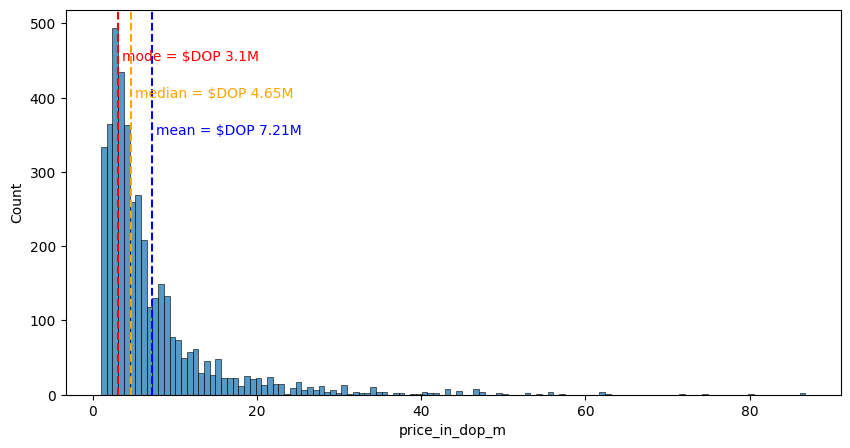

In [ ]:
"""
With seaborn create a hist plot of the price_in_dop_m
and label the highest frequency of the price_in_dop_m with the text
"""
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=df_filtered, x="price_in_dop_m", ax=ax)
mode_x = df_filtered["price_in_dop_m"].mode()[0]
median_x = df_filtered["price_in_dop_m"].median()
mean_x = round(df_filtered["price_in_dop_m"].mean(), 2)
ax.axvline(mode_x, color="red", linestyle="--")
ax.axvline(median_x, color="orange", linestyle="--")
ax.axvline(mean_x, color="blue", linestyle="--")
plt.text(mode_x+0.5, 450, f"mode = $DOP {mode_x}M", color="red")
plt.text(median_x+0.5, 400, f"median = $DOP {median_x}M", color="orange")
plt.text(mean_x+0.5, 350, f"mean = $DOP {mean_x}M", color="blue")
plt.show()

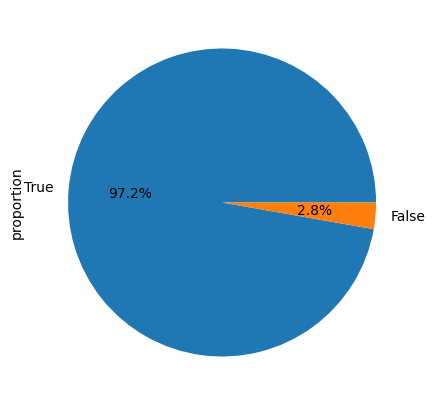

In [ ]:
# Create pie chart with percentages
fig, ax = plt.subplots(figsize=(10, 5))
df_filtered["ready_to_move"].value_counts(normalize=True).plot(kind="pie", ax=ax, autopct="%1.1f%%")
plt.show()

<Axes: xlabel='transaction_cleaned'>

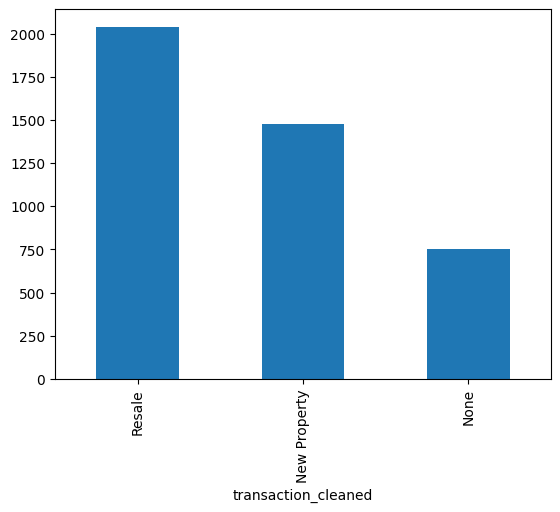

In [ ]:
df_filtered["transaction_cleaned"].value_counts(dropna=False).plot(kind="bar")

## Multivariable

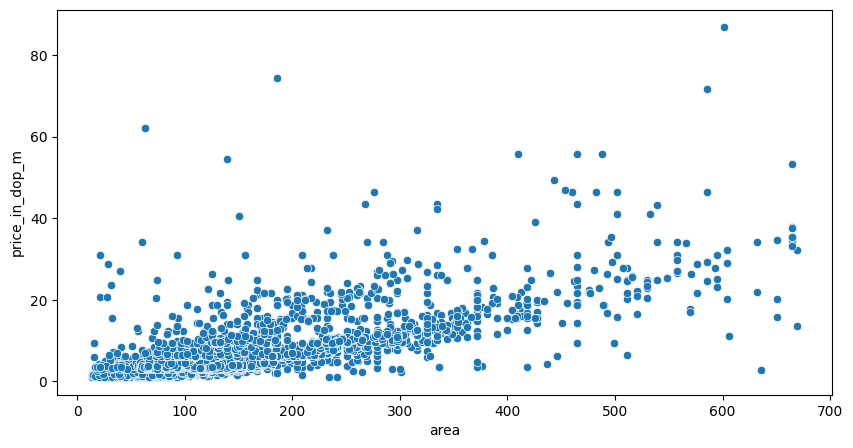

In [ ]:
"""
 Create scatter plot between price_in_dop_m and area
"""
fig, ax = plt.subplots(figsize=(10, 5))
# Remove outliers of area greater than perc 95
df_graph = df_filtered[df_filtered["area"] < df_filtered["area"].quantile(0.99)]
sns.scatterplot(data=df_graph, x="area", y="price_in_dop_m", ax=ax)
plt.show()

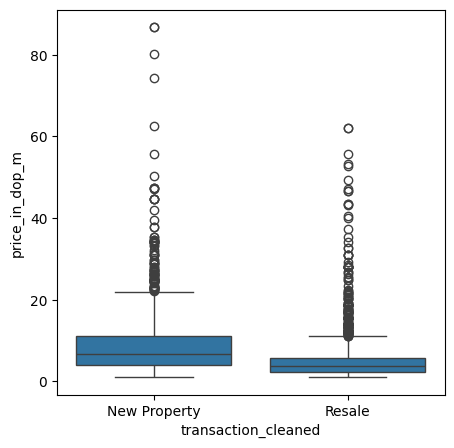

In [ ]:
"""
Create a box plot between price and transaction
"""
fig, ax = plt.subplots(figsize=(5, 5))
sns.boxplot(data=df_filtered, x="transaction_cleaned", y="price_in_dop_m", ax=ax)
plt.show()

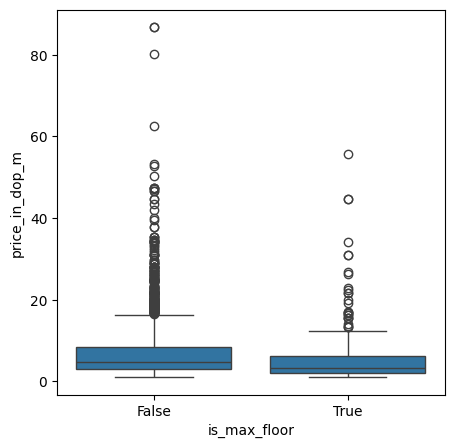

In [ ]:
"""
Create a box plot between price and is_max_floor
"""
fig, ax = plt.subplots(figsize=(5, 5))
sns.boxplot(data=df_filtered, x="is_max_floor", y="price_in_dop_m", ax=ax)
plt.show()

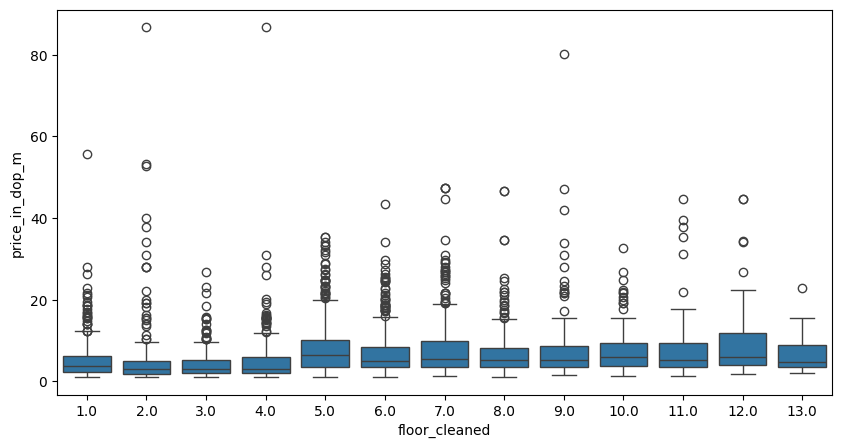

In [ ]:
"""
 Create box plot between price_in_dop_m and floor_cleaned
"""
fig, ax = plt.subplots(figsize=(10, 5))
# Remove outliers of area greater than perc 95
df_graph = df_filtered[df_filtered["floor_cleaned"] < df_filtered["floor_cleaned"].quantile(0.99)]
sns.boxplot(data=df_graph, x="floor_cleaned", y="price_in_dop_m", ax=ax)
plt.show()